# Idea: What if I trained on multiple trajectories (2)?

Maybe it can help thanks to the sensibility to initial conditions

In [2]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

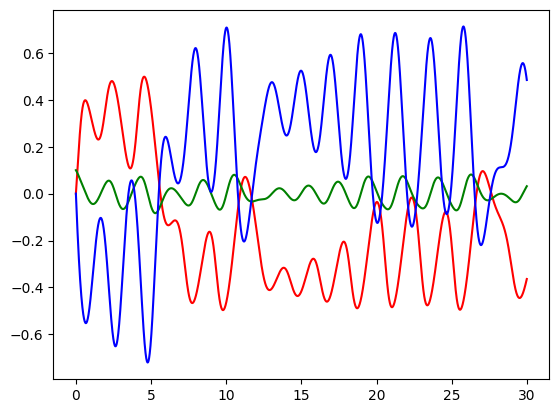

In [3]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 30

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [4]:
T_MAX = 60
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    y02 = jnp.array((-0.3,0,0.3))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.05))

    # training set
    sol_train1 = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train1 = sol_train1.ys[::5]
    t_train1 = sol_train1.ts[::5]

    sol_train2 = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y02, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_train2 = sol_train2.ys[::5]
    t_train2 = sol_train2.ts[::5]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.1))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

    x_val = sol_val.ys[::5]
    t_val = sol_val.ts[::5]

    return x_train1, t_train1,x_train2, t_train2, x_val, t_val, sol_train1, sol_train2, sol_val

In [5]:
x_train1, t_train1,x_train2, t_train2, x_val, t_val, sol_train1, sol_train2, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


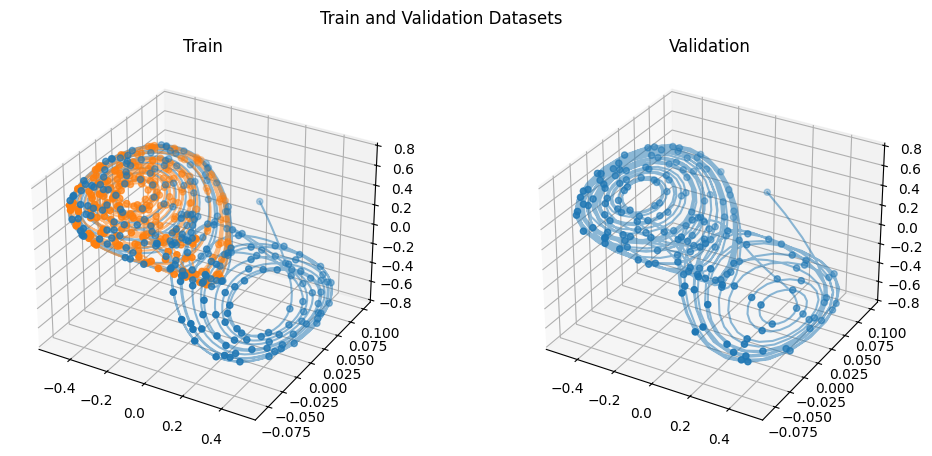

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].plot(sol_train1.ys[:, 0],sol_train1.ys[:, 1],sol_train1.ys[:, 2],alpha=0.5)
axes[0].plot(sol_train2.ys[:, 0],sol_train2.ys[:, 1],sol_train2.ys[:, 2],alpha=0.5)
axes[0].scatter(x_train1[:, 0],x_train1[:, 1],x_train1[:, 2],)
axes[0].scatter(x_train2[:, 0],x_train2[:, 1],x_train2[:, 2],)

axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5)
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2],)

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

In [288]:
t_train1.shape

(240,)

In [289]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [290]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [291]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=3,
            activation=jax.nn.leaky_relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def __call__(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)


In [292]:
def solve_ude_light(model, y0, ts, obs_fun):
    term = dfx.ODETerm(model)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-8)

    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        saveat=saveat,
        stepsize_controller=stepper,
        args=obs_fun,
        max_steps=4096*2
    )
    return sol.ys



In [293]:
@eqx.filter_value_and_grad
def loss_fn(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_ude_light(model, x0, ts, obs_fun)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [ ]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp_jit)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_jit_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


In [297]:
key = jr.PRNGKey(0)
linear_interp1 = LinearInterpolator(t_train1, x_train1)
linear_interp2 = LinearInterpolator(t_train2, x_train2)
linear_interp_val = LinearInterpolator(t_val, x_val)

linear_interp_jit1 = eqx.filter_jit(linear_interp1)
linear_interp_jit2 = eqx.filter_jit(linear_interp2)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)
ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    # train 1 and 2
    ude_pem, opt_state, loss1 = train_step(ude_pem, opt_state, x_train1[0], x_train1, t_train1, optimizer, linear_interp_jit1)
    val_loss = loss_fn(ude_pem, x_val[0], x_val, t_val, linear_interp_jit_val)[0]

    print(f"{i}\t{loss1:.4e}\t{val_loss:.4e}")


0	1.3997e-02	1.2085e-02
1	1.3737e-02	1.3006e-02
2	1.4179e-02	1.1973e-02
3	1.3400e-02	1.1911e-02
4	1.3695e-02	1.1813e-02
5	1.3571e-02	1.1710e-02
6	1.3211e-02	1.2053e-02
7	1.3311e-02	1.2113e-02
8	1.3323e-02	1.1734e-02
9	1.3067e-02	1.1459e-02
10	1.2976e-02	1.1419e-02
11	1.3045e-02	1.1350e-02
12	1.2942e-02	1.1309e-02
13	1.2766e-02	1.1426e-02
14	1.2737e-02	1.1496e-02
15	1.2733e-02	1.1332e-02
16	1.2602e-02	1.1092e-02
17	1.2463e-02	1.0950e-02
18	1.2417e-02	1.0861e-02
19	1.2343e-02	1.0784e-02
20	1.2187e-02	1.0788e-02
21	1.2069e-02	1.0801e-02
22	1.1998e-02	1.0658e-02
23	1.1857e-02	1.0416e-02
24	1.1685e-02	1.0222e-02
25	1.1560e-02	1.0069e-02
26	1.1406e-02	9.9344e-03
27	1.1186e-02	9.8455e-03
28	1.0988e-02	9.6924e-03
29	1.0779e-02	9.3872e-03
30	1.0495e-02	9.0635e-03
31	1.0217e-02	8.7728e-03
32	9.9022e-03	8.4904e-03
33	9.5157e-03	8.2042e-03
34	9.1345e-03	7.7651e-03
35	8.6699e-03	7.2521e-03
36	8.1671e-03	6.7494e-03
37	7.5959e-03	6.2476e-03
38	6.9618e-03	5.6167e-03
39	6.2346e-03	4.9559e-03
40	5.4655e

In [298]:
eqx.tree_serialise_leaves("./models_weights/31_6_ude_multi.eqx", ude_pem_multi)
eqx.tree_serialise_leaves("./models_weights/31_6_ude.eqx", ude_pem)


In [299]:
import pandas as pd 

losses_mult = jnp.asarray(pd.read_csv("./losses/31_6_multiple_training.txt", sep='\t'))
losses_sing = jnp.asarray(pd.read_csv("./losses/31_6_single_training.txt", sep='\t'))


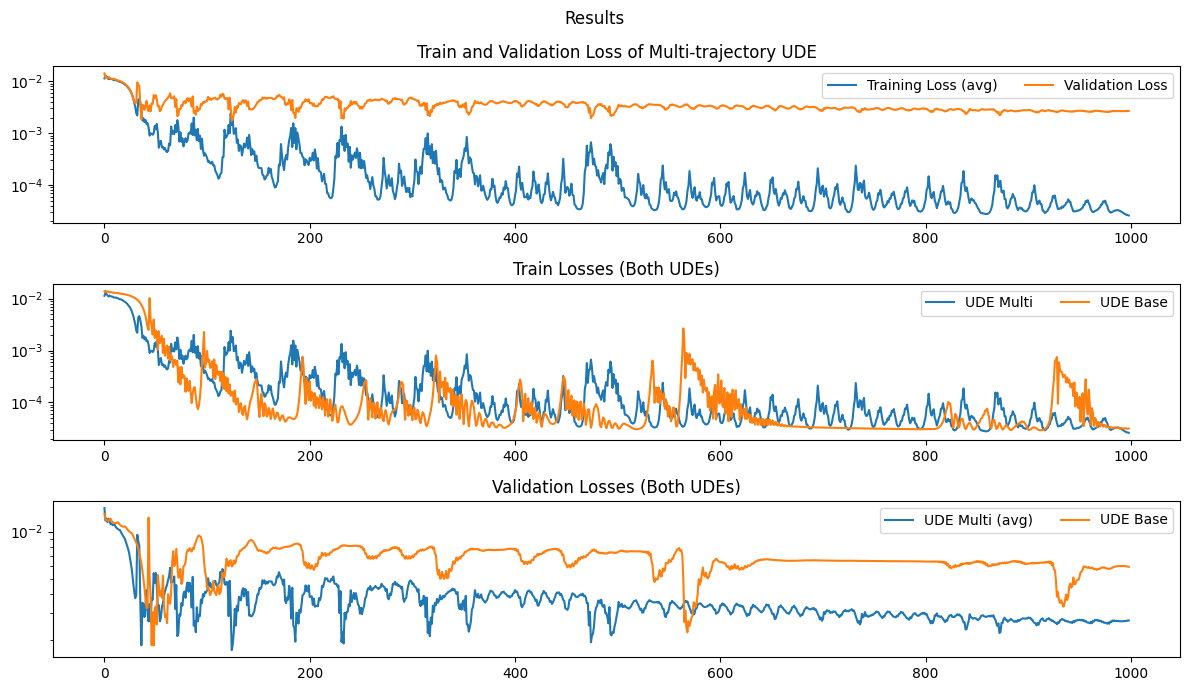

In [301]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7))

plt.sca(axes[1])
plt.semilogy(0.5 * (losses_mult[:, 1] + losses_mult[:, 2]), label="UDE Multi")
plt.semilogy(losses_sing[:, 1], label="UDE Base")
plt.title("Train Losses (Both UDEs)")
plt.legend(ncol=2)

plt.sca(axes[2])
plt.semilogy(losses_mult[:, 3], label="UDE Multi (avg)")
plt.semilogy(losses_sing[:, 2], label="UDE Base")
plt.title("Validation Losses (Both UDEs)")
plt.legend(ncol=2)

plt.sca(axes[0])
plt.semilogy(0.5 * (losses_mult[:, 1] + losses_mult[:, 2]), label="Training Loss (avg)")
plt.semilogy(losses_mult[:, 3], label="Validation Loss")
plt.title("Train and Validation Loss of Multi-trajectory UDE")

plt.legend(ncol=2)

plt.suptitle("Results")

plt.tight_layout()

plt.show()

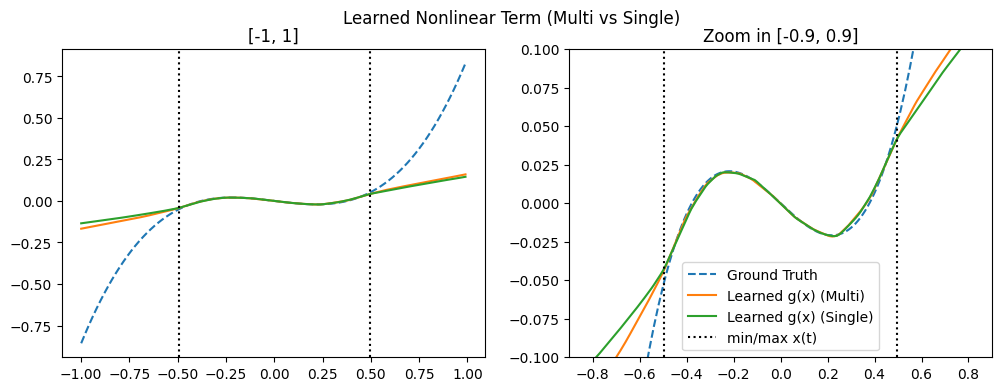

In [310]:
# plot learned network
# plot learned network
y_hats = []
y_hats_single = []
ys = []
for x in (x_space:=jnp.arange(-1, 1, 0.01)):
    y_hats.append(ude_pem_multi.net(x))
    y_hats_single.append(ude_pem.net(x))
    ys.append(A*x**3 + C*x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(axes[0])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x) (Multi)")
plt.plot(x_space, y_hats_single, label="Learned g(x) (Single)")
plt.axvline(x_train1[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train1[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.title("[-1, 1]")

plt.sca(axes[1])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x) (Multi)")
plt.plot(x_space, y_hats_single, label="Learned g(x) (Single)")

plt.axvline(x_train1[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train1[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.xlim(-0.9, 0.9)
plt.ylim(-0.1, 0.1)
plt.title("Zoom in [-0.9, 0.9]")

plt.legend()
plt.suptitle("Learned Nonlinear Term (Multi vs Single)")

plt.show()

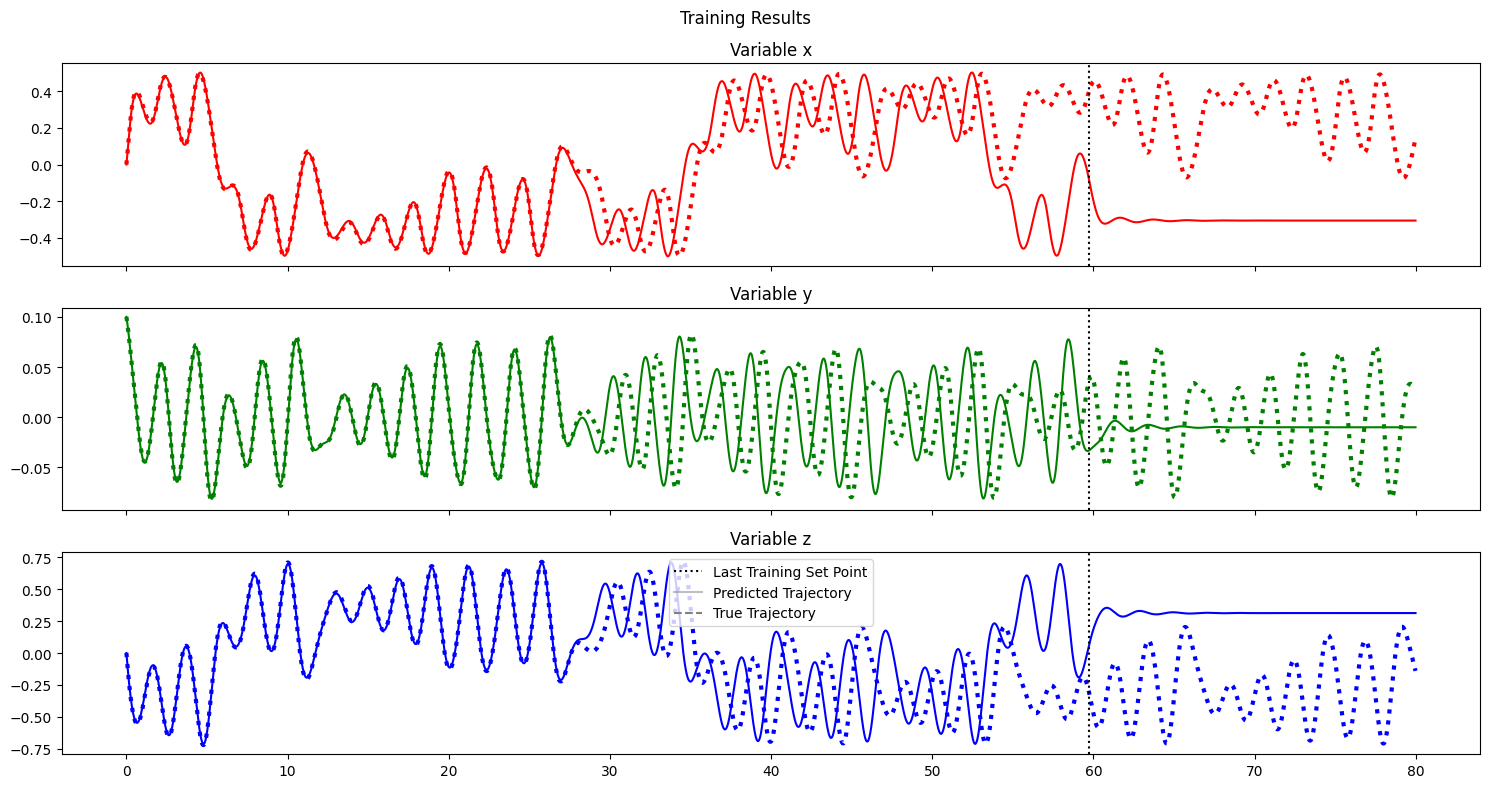

In [314]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 80

solver = dfx.Tsit5()
y0 = x_train1[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp_jit1, saveat=saveat, stepsize_controller=stepper, max_steps=10000).ys


for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval, traj_final[:, i], color=col_dict[i],)
    plt.plot(t_eval, traj_true[:, i], color=col_dict[i], linestyle=':', linewidth=3)
    plt.axvline(t_train1[-1], color="k", linestyle=":", label="Last Training Set Point")
    plt.title(f"Variable {var_dict[i]}")

plt.plot([], [], color="gray", alpha=0.5, label="Predicted Trajectory")
plt.plot([], [], color="gray", linestyle="--", label="True Trajectory")

plt.legend()
plt.suptitle("Training Results")
plt.tight_layout()
plt.show()

In [16]:
sindy_baseline = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000, threshold=0.5, verbose=True)
)

sindy_baseline.fit(x_train1, t_train1, feature_names=['x', 'y', 'z'])


sindy_baseline.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 5.6037e+00 ... 1.0511e+01 ...         13 ... 1.6115e+01
         1 ... 2.7565e+00 ... 1.1273e+01 ...         12 ... 1.4030e+01
         2 ... 2.6865e+00 ... 1.1341e+01 ...         12 ... 1.4028e+01
(x)' =  1.428 x +  9.575 y + -14.769 x^3 + -8.115 x^2 z + -3.190 x z^2
(y)' =  0.900 x + -0.911 y +  0.903 z
(z)' = -15.103 y + -4.389 x^2 y + -12.026 x y z + -3.538 y z^2


In [316]:
# Train with PEM
X_dot = jnp.zeros_like(x_train1)

for i, (t, x) in enumerate(zip(t_train1, x_train1)):
    X_dot = X_dot.at[i, :].set(ude_pem(t, x, linear_interp_jit1))

sindy_ude = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000, threshold=0.5, verbose=True)
)

sindy_ude.fit(x_train1, t_train1, feature_names=['x', 'y', 'z'], x_dot=X_dot )

sindy_ude.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 1.1299e+01 ... 1.2004e+01 ...         15 ... 2.3303e+01
         1 ... 2.5683e+00 ... 1.3210e+01 ...         15 ... 1.5778e+01
(x)' =  1.415 x +  10.036 y + -14.260 x^3 + -9.339 x^2 z + -5.168 x z^2 + -1.352 z^5
(y)' =  1.000 x + -1.000 y +  1.000 z
(z)' = -16.000 y


In [317]:
t_train_new = jnp.arange(0, N:=15, 0.01) # N is the part where the model starts underfitting badly
x_train_new = solve_ude_light(ude_pem, x_train1[0], t_train_new, linear_interp_jit1)

X_dot = jnp.zeros_like(x_train_new)

for i, (t, x) in enumerate(zip(t_train_new, x_train_new)):
    X_dot = X_dot.at[i, :].set(ude_pem(t, x, linear_interp_jit1))



In [318]:
sindy_ude_alt = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.STLSQ(max_iter=1000000,threshold=0.8, verbose=True)
)

sindy_ude_alt.fit(x_train_new, t_train_new, feature_names=['x', 'y', 'z'], x_dot=X_dot)

sindy_ude_alt.print()

 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 1.5458e+01 ... 1.7448e+01 ...          9 ... 3.2906e+01
         1 ... 2.6071e+00 ... 1.8322e+01 ...          8 ... 2.0929e+01
         2 ... 2.1436e+00 ... 1.8238e+01 ...          8 ... 2.0382e+01
(x)' =  1.303 x +  9.965 y + -9.126 x^3 +  0.158 x^2 z
(y)' =  1.003 x + -1.015 y +  1.003 z
(z)' = -16.023 y


In [11]:
def learned_sindy_model_ude1(t, xyz, args):
    x, y, z = xyz
    return jnp.array(
        [
            1.415 * x + 10.036 * y - 14.260 * (x**3) - 9.339 * (x**2) * z - 5.168 * x * (z**2) - 1.352 * (z**5),
            1.000 * x - 1.000 * y + 1.000 * z,
            -16.000 * y,
        ]
    )


def learned_sindy_model_2_ude2(t, xyz, args):
    x, y, z = xyz
    return jnp.array(
        [
            1.303 * x + 9.965 * y - 9.126 * (x**3) + 0.158 * (x**2) * z,
            1.003 * x - 1.015 * y + 1.003 * z,
            -16.023 * y,
        ]
    )


def learned_sindy_model_3_baseline(t, xyz, args):
    x, y, z = xyz
    return jnp.array(
        [
            1.428 * x + 9.575 * y - 14.769 * (x**3) - 8.115 * (x**2) * z - 3.190 * x * (z**2),
            0.9 * x - 0.911 * y + 0.903 * z,
            -15.103 * y - 4.389 * (x**2) * y - 12.026 * x * y * z - 3.538 * y * (z**2)
        ]
    )


In [12]:
term = dfx.ODETerm(chua_model)
term_sindy = dfx.ODETerm(learned_sindy_model_ude1)
term_sindy2 = dfx.ODETerm(learned_sindy_model_2_ude2)
term_sindy3 = dfx.ODETerm(learned_sindy_model_3_baseline)

solver = dfx.Tsit5()
y0 = x_train1[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

sol = dfx.diffeqsolve(
    term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper
    )
traj_true = sol.ys

traj_sindy1 = dfx.diffeqsolve(
    term_sindy, 
    solver, 
    t0=0, t1=T_MAX, dt0=0.01, 
    y0=y0, 
    saveat=saveat, 
    stepsize_controller=stepper,
    ).ys

traj_sindy2 = dfx.diffeqsolve(
    term_sindy2, 
    solver, 
    t0=0, t1=T_MAX, dt0=0.01, 
    y0=y0, 
    saveat=saveat, 
    stepsize_controller=stepper,
    ).ys

traj_sindy3 = dfx.diffeqsolve(
    term_sindy3, 
    solver, 
    t0=0, t1=T_MAX, dt0=0.01, 
    y0=y0, 
    saveat=saveat, 
    stepsize_controller=stepper,
    ).ys


In [34]:
## Unite two plots above into one
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib import colormaps as cm 
from matplotlib import ticker

def show_trajectory_results(x0_train, model_real, model_sindy, name, t_config = dict(dt = 0.01, max=82)):
    term = dfx.ODETerm(model_real)
    term_sindy = dfx.ODETerm(model_sindy)

    solver = dfx.Tsit5()
    t_eval = jnp.arange(0, t_config['max'], t_config['dt'])
    saveat = dfx.SaveAt(ts=t_eval)
    stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

    sol_true = dfx.diffeqsolve(
        term, solver, t0=0, t1=t_config['max'], dt0=0.01, y0=x0_train, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper
        )
    sol_sindy = dfx.diffeqsolve(
        term_sindy, solver, t0=0, t1=t_config['max'], dt0=0.01, y0=x0_train, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper
        )
    
    traj_true = sol_true.ys
    traj_sindy = sol_sindy.ys

    fig, axes = plt.subplot_mosaic([
        ["top_left", "top_right"], ["middle", "middle"], ["bottom", "bottom"]
    ], per_subplot_kw={'top_left': dict(projection='3d'), 'top_right': dict(projection='3d')}, 
    gridspec_kw={'height_ratios': [2, 1, 1], 'wspace': 0},
    figsize=(15, 12))


    axes['top_left'].plot(traj_true[:, 0],traj_true[:, 1],traj_true[:, 2], alpha=1, linestyle='--', label="Ground Truth" )
    axes['top_left'].plot(traj_sindy[:, 0],traj_sindy[:, 1],traj_sindy[:, 2], alpha=1, label="SINDy-learned Trajectory")

    axes['top_left'].set_title("(a) Two Trajectories (3D)")

    axes['top_left'].set_xlabel("x")
    axes['top_left'].set_ylabel("y")
    axes['top_left'].set_zlabel("z")

    # Second figure
    error = jnp.linalg.norm(traj_true - traj_sindy, axis=1)

    # Coordinates
    x = traj_true[:,0]
    y = traj_true[:,1]
    z = traj_true[:,2]

    # Build line segments
    points = jnp.array([x, y, z]).T.reshape(-1,1,3)
    segments = jnp.concatenate([points[:-1], points[1:]], axis=1)

    # normalize stuff
    norm = Normalize(vmin=jnp.min(error), vmax=jnp.max(error))

    # line
    lc = Line3DCollection(
        segments,
        cmap='inferno',
        norm=norm
    )

    lc.set_array(error[:-1])
    lc.set_linewidth(1.5)

    # Figure
    axes['top_right'].add_collection3d(lc)

    # Axis limits
    axes['top_right'].set_xlim(x.min(), x.max())
    axes['top_right'].set_ylim(y.min(), y.max())
    axes['top_right'].set_zlim(z.min(), z.max())

    axes['top_right'].set_xlabel('x')
    axes['top_right'].set_ylabel('y')
    axes['top_right'].set_zlabel('z')

    axes['top_right'].set_title('(b) Absolute errors of fit')

    # Colorbar
    cbar = fig.colorbar(lc, ax=axes['top_right'], pad=0.1)
    cbar.set_label('Absolute Error')

    plt.suptitle(name)

    # Second row: comparison of x trajectory
    axes['middle'].plot(sol_true.ts, traj_sindy[:, 0], color='blue')
    axes['middle'].plot(sol_true.ts, traj_true[:, 0], color='red', linestyle=":", linewidth=3)
    axes['middle'].set_title("(c) Two Trajectories in the $x$ variable (time series)")

    axes['bottom'].set_title("(d) Multiple simulations with different initial conditions")
    
    x0s = [
        x0_train,
        jnp.array([0.0001, 0   , 0.    ]),
        jnp.array([0.0001, -0.1   , 0.    ]),
    ]

    palette = ['r', 'g', 'b']

    for i, x0 in enumerate(x0s):
        sol_temp = dfx.diffeqsolve(
        term_sindy, solver, t0=0, t1=t_config['max'], dt0=0.01, y0=x0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper
        )

        axes['bottom'].plot(sol_temp.ts, sol_temp.ys[:, 0], color=palette[i])

    axes['middle'].xaxis.set_major_locator(ticker.MultipleLocator(5))
    axes['bottom'].xaxis.set_major_locator(ticker.MultipleLocator(5))

    plt.show()

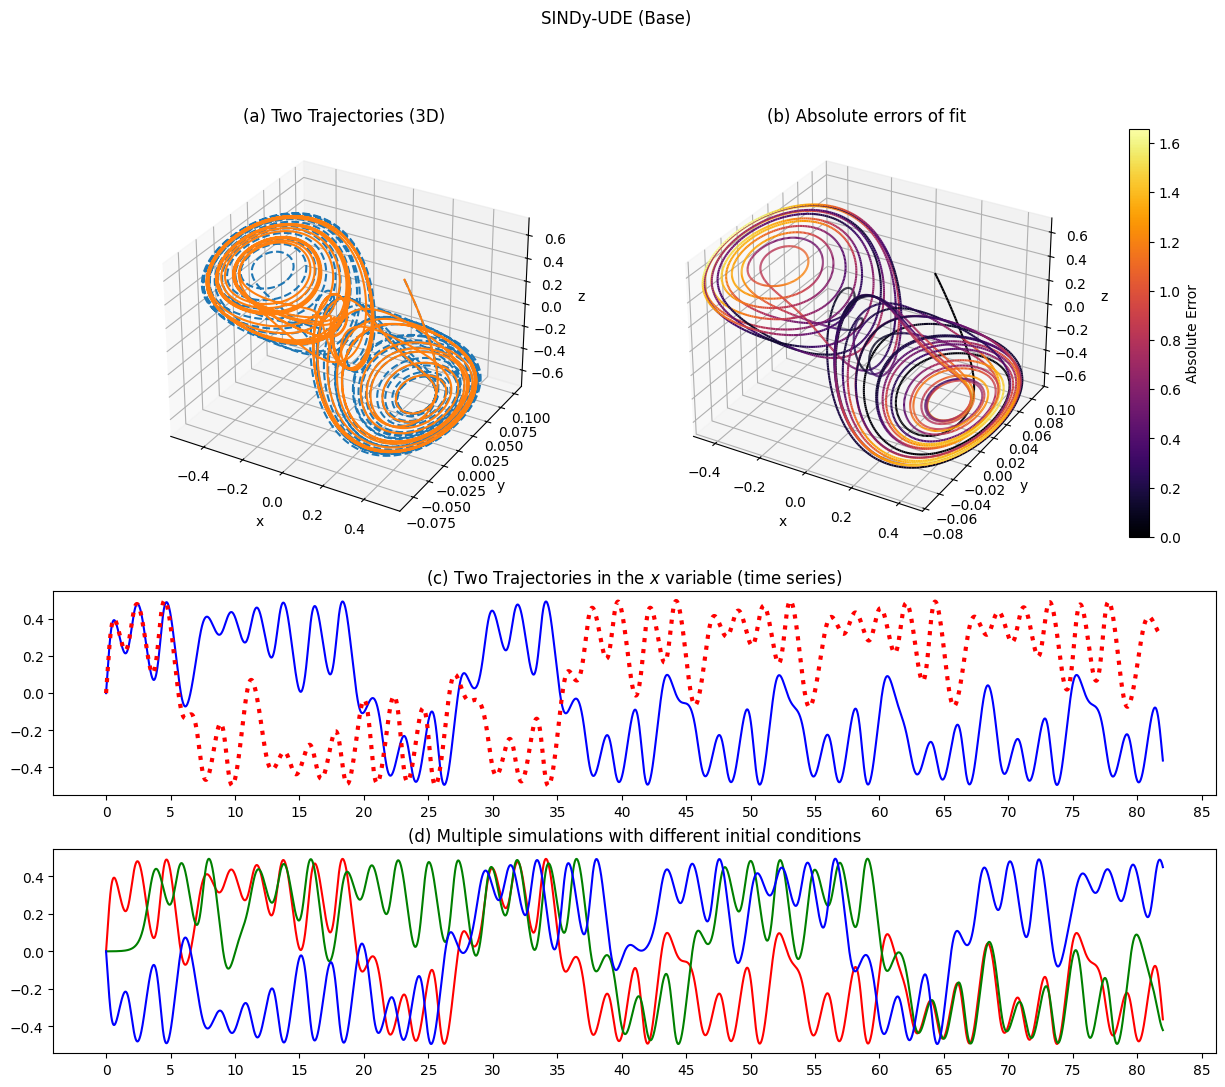

In [35]:
show_trajectory_results(x_train1[0], chua_model, learned_sindy_model_ude1, "SINDy-UDE (Base)") # UDE-SINDy (all)

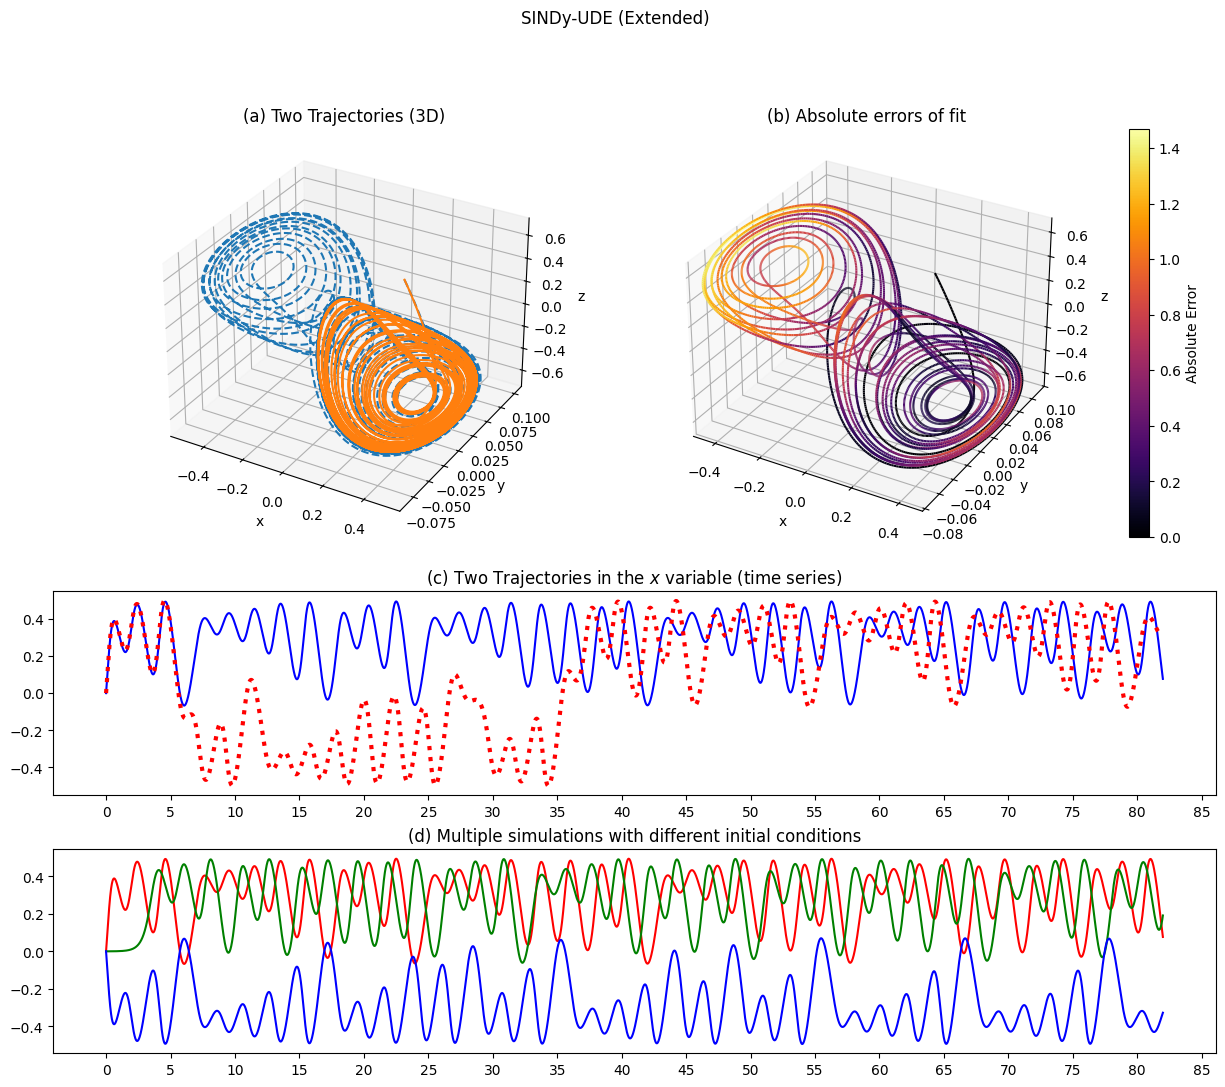

In [36]:
show_trajectory_results(x_train1[0], chua_model, learned_sindy_model_2_ude2,  "SINDy-UDE (Extended)") # UDE-SINDy (bigger dataset)) 

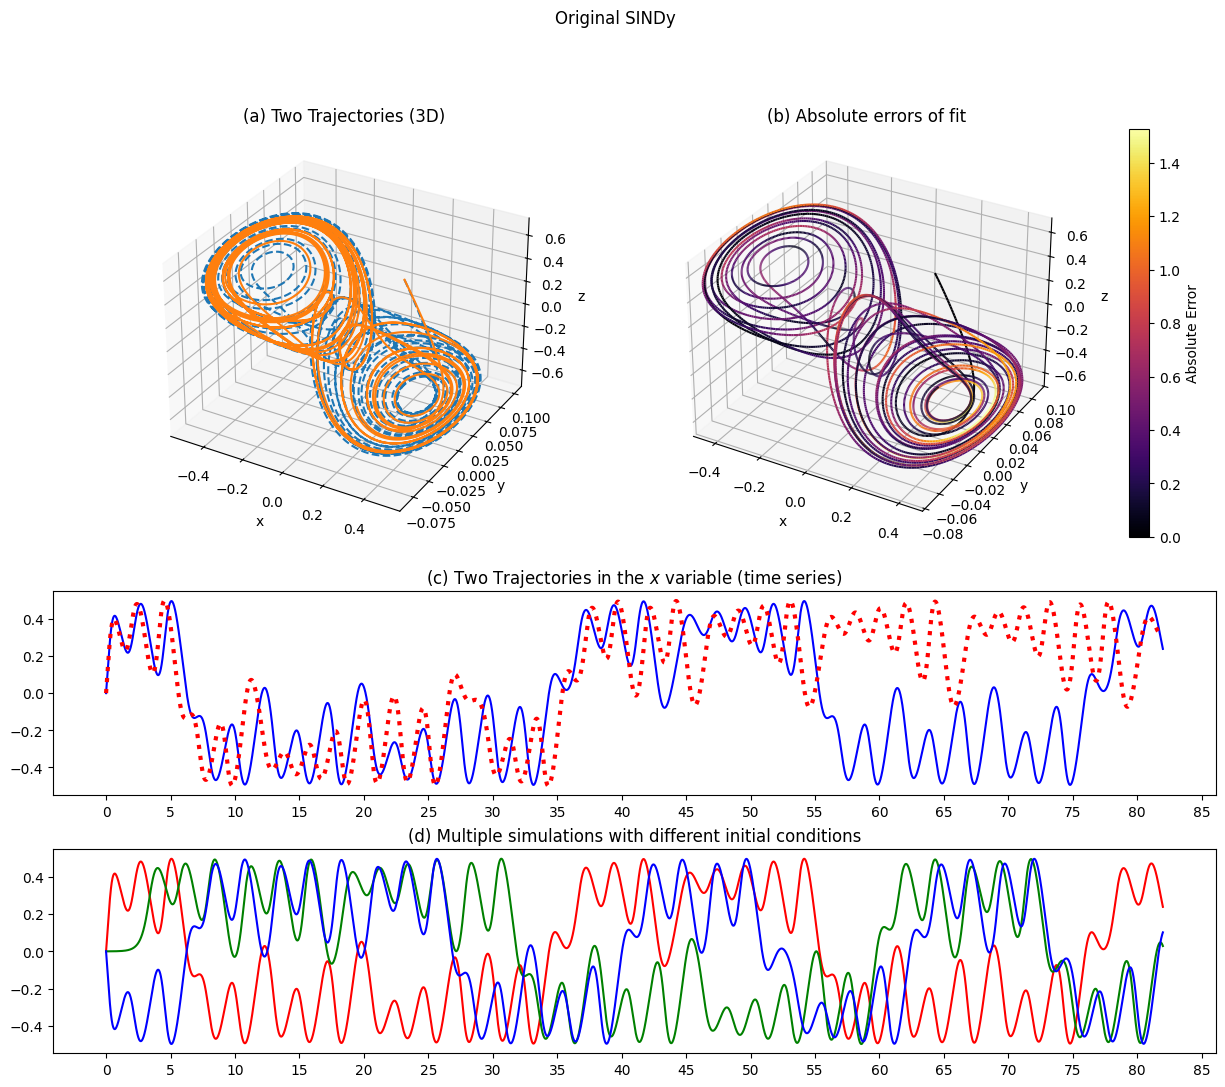

In [37]:
show_trajectory_results(x_train1[0], chua_model, learned_sindy_model_3_baseline, "Original SINDy") # Baseline 

Here, it seems using SINDy without extending data seems better

In [13]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel="gaussian").fit(traj_true)
base_likelihood = kde.score_samples(traj_true).sum()

loss1 = base_likelihood - kde.score_samples(traj_sindy1).sum()
loss2 = base_likelihood - kde.score_samples(traj_sindy2).sum()
loss3 = base_likelihood - kde.score_samples(traj_sindy3).sum()

print(f"LOSSES (Nats):\n\tBaseline: {loss3}\n\tUDE 1 (denser data): {loss2}\n\tUDE 2 (normal): {loss1}")

LOSSES (Nats):
	Baseline: 19.94226214412629
	UDE 1 (denser data): -26.17357663945586
	UDE 2 (normal): -29.021770723480586


In [17]:
features = sindy_baseline.get_feature_names()

In [ ]:
chua_coef = jnp.zeros((3, len(features)))

chua_coef = chua_coef.at[0, 0:2].set(jnp.array([1.43, 10]))
chua_coef = chua_coef.at[0, 9].set(-10)

chua_coef = chua_coef.at[1, 0:3].set(jnp.array([1, -1, 1]))

chua_coef = chua_coef.at[2, 1].set(-16)

chua_coef

In [330]:
from sklearn.metrics import mean_squared_error
print("MSE ERRORS FROM THE TRUE MODEL (COEFFICIENTS)")

print(f"\tBASELINE: {mean_squared_error(chua_coef, sindy_baseline.optimizer.coef_) }")
print(f"\tUDE: {mean_squared_error(chua_coef, sindy_ude.optimizer.coef_) }")
print(f"\tUDE (EXTENDED): {mean_squared_error(chua_coef, sindy_ude_alt.optimizer.coef_) }")


MSE ERRORS FROM THE TRUE MODEL (COEFFICIENTS)
	BASELINE: 1.6739884560370657
	UDE: 0.8115959369665235
	UDE (EXTENDED): 0.0048936788960016716


In [331]:
features_processed = []
for feature in features:
    features_processed.append(f"${feature}$")

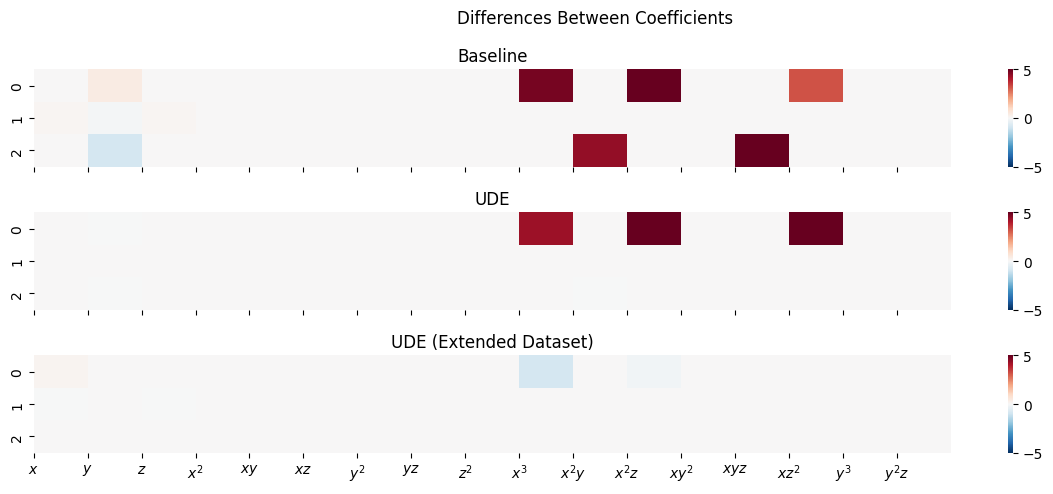

In [332]:
import seaborn as sns 
from matplotlib.colors import TwoSlopeNorm

diff_mat_1 = chua_coef[:, :17]-sindy_baseline.optimizer.coef_[:, :17]
diff_mat_2 = chua_coef[:, :17]-sindy_ude.optimizer.coef_[:, :17]
diff_mat_3 = chua_coef[:, :17]-sindy_ude_alt.optimizer.coef_[:, :17]

max_1 = jnp.max(jnp.abs(jnp.array([diff_mat_1.min(), diff_mat_1.max()])))
max_2 = jnp.max(jnp.abs(jnp.array([diff_mat_2.min(), diff_mat_3.max()])))
max_3 = jnp.max(jnp.abs(jnp.array([diff_mat_2.min(), diff_mat_3.max()])))

norm_col = TwoSlopeNorm(
    vmin = -5,
    vmax = 5,
    vcenter = 0
)

fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

sns.heatmap(diff_mat_1, cmap="RdBu_r", norm=norm_col, ax=axes[0])
sns.heatmap(diff_mat_2, cmap="RdBu_r", norm=norm_col, ax=axes[1])
sns.heatmap(diff_mat_3, cmap="RdBu_r", norm=norm_col, ax=axes[2])

axes[0].set_title("Baseline")
axes[1].set_title("UDE")
axes[2].set_title("UDE (Extended Dataset)")

plt.xticks(range(17), labels=features_processed[:17])
plt.suptitle("Differences Between Coefficients")
plt.tight_layout()

plt.show()

In [17]:
import optimistix as optx
# model calibration with optimization techniques
# calibrate the model with the best coefficients (according to MSE)


def identified_chua(t, xyz, args):
    a1, a2, a3, a4, b1, b2, b3, c1 = args
    x, y, z = xyz
    return jnp.array(
        [
            a1 * x + a2 * y + a3 * (x**3) + a4 * (x**2) * z,
            b1 * x + b2 * y + b3 * z,
            c1 * y,
        ]
    )


# Try to use a shorter time series first
x_train_reduced = x_train1[:25]
t_train_reduced = t_train1[:25]

@eqx.filter_jit
def residual(args, _):
    # solve
    term = dfx.ODETerm(identified_chua)
    solver = dfx.Tsit5()
    y0 = jnp.array((0.0001, 0.1, 0))

    # solve equation
    sol = dfx.diffeqsolve(
        term, solver, y0=y0, t0=t_train_reduced[0], t1=t_train_reduced[-1], saveat=dfx.SaveAt(ts=t_train_reduced), args=args, dt0=(t_train_reduced[1]-t_train_reduced[0]),
        adjoint=dfx.DirectAdjoint(),
    ).ys 
    
    return sol - x_train_reduced


initial_guess = jnp.array([1.303, 9.965, -9.126, 0.158, 1.003, -1.015, 1.003, -16.023])

residual_solver = optx.LevenbergMarquardt(rtol=1e-8, atol=1e-8, verbose=True)

fixed_params = optx.least_squares(residual, residual_solver, initial_guess, max_steps=10000)

Step: 0, Accepted steps: 0, Steps since acceptance: 0, Loss on this step: 0.020611094418598583, Loss on the last accepted step: 0.0, Step size: 1.0, y: [  1.303   9.965  -9.126   0.158   1.003  -1.015   1.003 -16.023], y on the last accepted step: [  1.303   9.965  -9.126   0.158   1.003  -1.015   1.003 -16.023]
Step: 1, Accepted steps: 1, Steps since acceptance: 0, Loss on this step: 0.0008164880281582838, Loss on the last accepted step: 0.020611094418598583, Step size: 3.5, y: [  1.3392052    9.96321977  -9.12455551   0.15661552   1.01924198
  -1.00504394   1.01507802 -16.02373185], y on the last accepted step: [  1.3392052    9.96321977  -9.12455551   0.15661552   1.01924198
  -1.00504394   1.01507802 -16.02373185]
Step: 2, Accepted steps: 2, Steps since acceptance: 0, Loss on this step: 0.00046410872212727526, Loss on the last accepted step: 0.0008164880281582838, Step size: 12.25, y: [  1.35020698   9.96458029  -9.1276665    0.15871687   1.01694417
  -0.99628798   1.01336936 -16.0

In [18]:
fixed_params.value

Array([ 1.42938163e+00,  1.00003766e+01, -9.99754206e+00, -1.10794968e-03,
        9.99808913e-01, -9.99722336e-01,  9.99871724e-01, -1.60006596e+01],      dtype=float64)

In [19]:
# It worked! (kinda) Plot to believe
def fixed_chua(t, xyz, args):
    a1, a2, a3, a4, b1, b2, b3, c1 = fixed_params.value
    x, y, z = xyz
    return jnp.array(
        [
            a1 * x + a2 * y + a3 * (x**3) + a4 * (x**2) * z,
            b1 * x + b2 * y + b3 * z,
            c1 * y,
        ]
    )

In [20]:
# solve
term_fixed = dfx.ODETerm(fixed_chua)
solver = dfx.Tsit5()
y0 = jnp.array((0.0001, 0.1, 0))
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# solve equation
sol = dfx.diffeqsolve(
    term_fixed, solver, y0=y0, t0=0, t1=T_MAX, dt0=0.01, saveat=saveat, stepsize_controller=stepper
).ys 

# get original solution
sol_true = dfx.diffeqsolve(
    terms=term, solver=solver, y0=y0, t0=0, t1=T_MAX, dt0=0.01,saveat=saveat,stepsize_controller=stepper,
    args=(ALPHA, BETA, GAMMA, A, C)
).ys

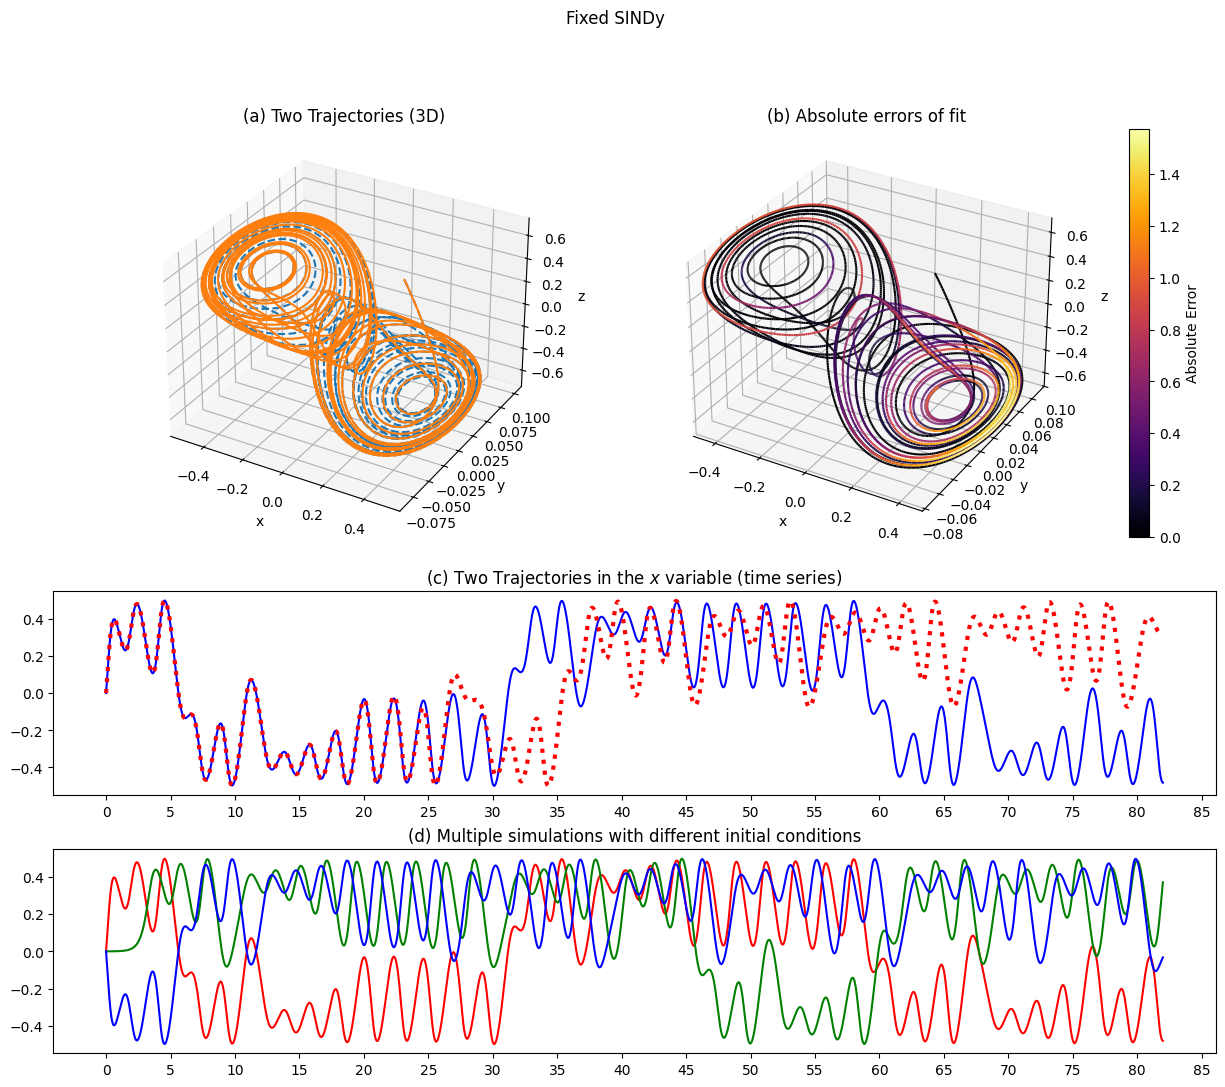

In [21]:
show_trajectory_results(x_train1[0], chua_model, fixed_chua, "Fixed SINDy")

In [23]:
# LLEs (?)

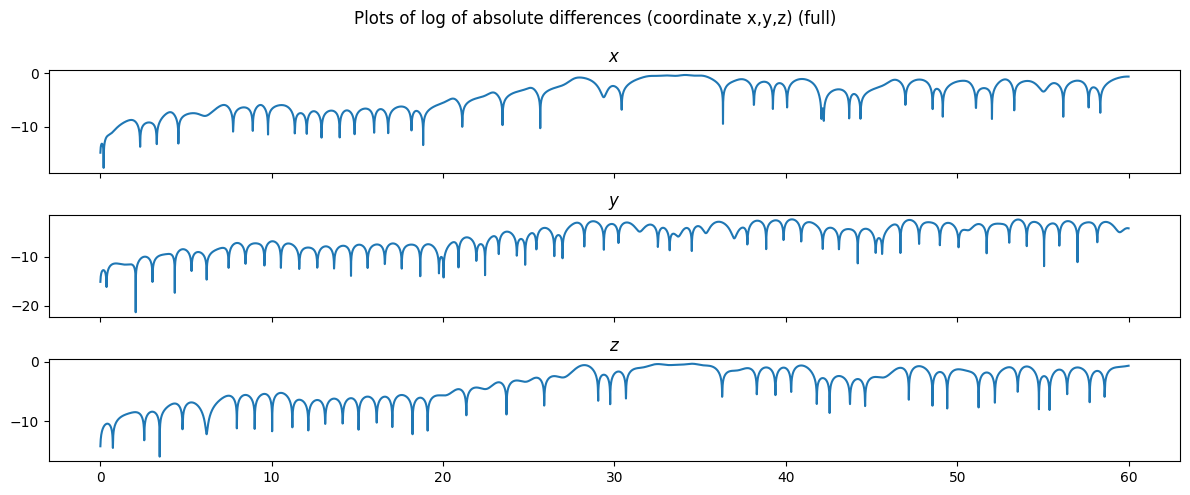

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (full)")

plt.sca(axes[0])
plt.plot(t_eval[1:], diff_x := jnp.log(jnp.abs(sol[1:, 0] - sol_true[1:, 0])))
plt.title("$x$")
plt.sca(axes[1])
plt.plot(t_eval[1:], diff_y := jnp.log(jnp.abs(sol[1:, 1] - sol_true[1:, 1])))
plt.title("$y$")

plt.sca(axes[2])
plt.plot(t_eval[1:], diff_z := jnp.log(jnp.abs(sol[1:, 2] - sol_true[1:, 2])))
plt.title("$z$")

plt.tight_layout()

plt.show()


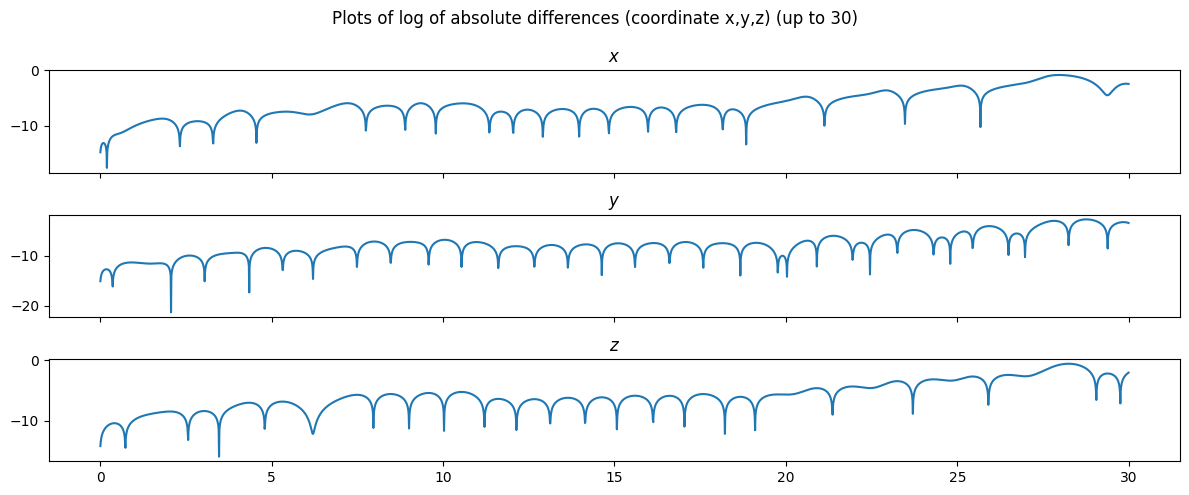

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (up to 30)")

MAX = 3000

plt.sca(axes[0])
plt.plot(t_eval[1:MAX], diff_x := jnp.log(jnp.abs(sol[1:MAX, 0] - sol_true[1:MAX, 0])))
plt.title("$x$")
plt.sca(axes[1])
plt.plot(t_eval[1:MAX], diff_y := jnp.log(jnp.abs(sol[1:MAX, 1] - sol_true[1:MAX, 1])))
plt.title("$y$")

plt.sca(axes[2])
plt.plot(t_eval[1:MAX], diff_z := jnp.log(jnp.abs(sol[1:MAX, 2] - sol_true[1:MAX, 2])))
plt.title("$z$")

plt.tight_layout()

plt.show()


In [45]:
from sklearn.linear_model import LinearRegression
reg_x = LinearRegression(fit_intercept=False)
reg_y = LinearRegression(fit_intercept=False)
reg_z = LinearRegression(fit_intercept=False)

# manually modify intercept

reg_x.fit(t_eval[1:MAX].reshape(-1, 1), diff_x-diff_x[0]) # Fit on the zero-centered datasets
reg_y.fit(t_eval[1:MAX].reshape(-1, 1), diff_y-diff_x[1])
reg_z.fit(t_eval[1:MAX].reshape(-1, 1), diff_z-diff_x[2])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
print(f"ESTIMATED LLE COEFFICIENTS:\n\tx: {reg_x.coef_}\n\ty: {reg_y.coef_}\n\tz: {reg_z.coef_}")

ESTIMATED LLE COEFFICIENTS:
	x: [0.48370191]
	y: [0.36748697]
	z: [0.45319098]


In [47]:
predict_x = reg_x.predict(t_eval[1:MAX].reshape(-1, 1))+diff_x[0]
predict_y = reg_x.predict(t_eval[1:MAX].reshape(-1, 1))+diff_y[0]
predict_z = reg_x.predict(t_eval[1:MAX].reshape(-1, 1))+diff_z[0]


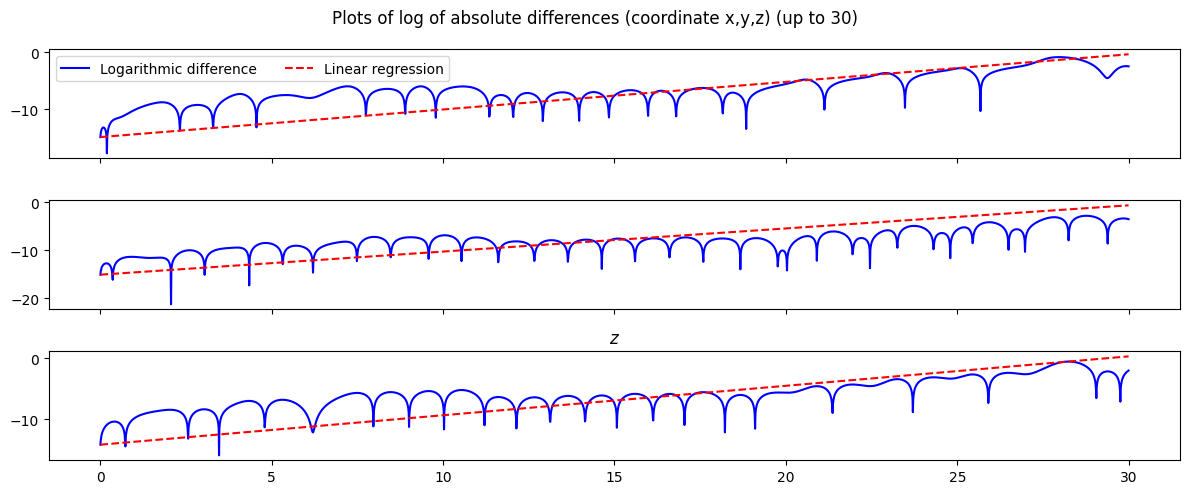

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

plt.suptitle("Plots of log of absolute differences (coordinate x,y,z) (up to 30)")

predicts = {
    0: predict_x,
    1: predict_y,
    2: predict_z
}

diffs = {
    0: diff_x, 
    1: diff_y, 
    2: diff_z
}

plt.sca(axes[0])
plt.plot([], [], color="blue", label="Logarithmic difference")
plt.plot([], [], linestyle="--", color='red', label ="Linear regression")
plt.legend(ncol=2)

for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval[1:MAX], diffs[i], color="blue")
    plt.plot(t_eval[1:MAX], predicts[i], linestyle="--", color='red')

plt.title("$z$")

plt.tight_layout()

plt.show()
